## **Risk Parity Portfolio**
---

### **1. Financial Assets**

In [1]:
import math
import numpy as np
import pandas as pd
from pylab import plt
import matplotlib.pyplot as plt
from datetime import datetime
plt.style.use('seaborn-v0_8-colorblind') 
np.set_printoptions(suppress = True)
%config InlineBackend.figure_format = 'svg'

In [2]:
portfolio_data = str(input("Which Portfolio report do you want to generate?\na. Aspect Partners\nb. SPY + Long Vol\nc. SPY + Long Bond\nd. State Street Global Allocation ETF: "))

Which Portfolio report do you want to generate?
a. Aspect Partners
b. SPY + Long Vol
c. SPY + Long Bond
d. State Street Global Allocation ETF:  a


In [3]:
# Create a dictionary with the multiple options:
data_csv = {
    'a': 'aspect_partners.csv', 
    'b': 'SPY_Long_Vol.csv', 
    'c': 'SPY_Long_Bond.csv', 
    'd': 'State_Street_ETF.csv'
}
file_name = data_csv.get(portfolio_data, "Invalid Option")
data = pd.read_csv(file_name, index_col = 0, parse_dates = True)
data = data.loc['2024-01-02':]
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 541 entries, 2024-01-02 to 2026-02-27
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   APDFX   541 non-null    float64
 1   ASFYX   541 non-null    float64
 2   CASH    541 non-null    float64
 3   DSMC    541 non-null    float64
 4   GQGIX   541 non-null    float64
 5   IAGG    541 non-null    float64
 6   IAU     541 non-null    float64
 7   IEFA    541 non-null    float64
 8   PDBC    541 non-null    float64
 9   QMHIX   541 non-null    float64
 10  RSSB    541 non-null    float64
 11  SPY     541 non-null    float64
 12  TLT     541 non-null    float64
dtypes: float64(13)
memory usage: 59.2 KB


In [4]:
print(data.head())

               APDFX     ASFYX       CASH       DSMC      GQGIX       IAGG  \
Date                                                                         
2024-01-02  7.751785  8.815974  52.228386  33.574211  15.210287  46.083683   
2024-01-03  7.717294  8.738301  50.280014  32.928703  15.268047  46.157967   
2024-01-04  7.717294  8.718882  50.488770  32.821442  15.345061  45.944401   
2024-01-05  7.708673  8.709172  50.289955  32.850689  15.373942  45.897972   
2024-01-08  7.725916  8.777138  50.399296  33.146141  15.412449  45.981544   

                  IAU       IEFA       PDBC     QMHIX       RSSB         SPY  \
Date                                                                           
2024-01-02  38.939999  64.874077  12.146895  7.363545  20.058945  461.247467   
2024-01-03  38.639999  64.342636  12.312660  7.334819  19.920443  457.480591   
2024-01-04  38.669998  64.510460  12.257406  7.344395  19.790537  456.006989   
2024-01-05  38.660000  64.519775  12.321871  7.334819

### **2. Returns**

In [5]:
returns_df = data.pct_change().dropna()
print(returns_df.head())

               APDFX     ASFYX      CASH      DSMC     GQGIX      IAGG  \
Date                                                                     
2024-01-03 -0.004449 -0.008810 -0.037305 -0.019226  0.003797  0.001612   
2024-01-04  0.000000 -0.002222  0.004152 -0.003257  0.005044 -0.004627   
2024-01-05 -0.001117 -0.001114 -0.003938  0.000891  0.001882 -0.001011   
2024-01-08  0.002237  0.007804  0.002174  0.008994  0.002505  0.001821   
2024-01-09  0.001116 -0.006637 -0.006509 -0.008031 -0.003123 -0.002423   

                 IAU      IEFA      PDBC     QMHIX      RSSB       SPY  \
Date                                                                     
2024-01-03 -0.007704 -0.008192  0.013647 -0.003901 -0.006905 -0.008167   
2024-01-04  0.000776  0.002608 -0.004488  0.001306 -0.006521 -0.003221   
2024-01-05 -0.000259  0.000144  0.005259 -0.001304 -0.001593  0.001370   
2024-01-08 -0.007501  0.010983 -0.016443  0.007833  0.014551  0.014276   
2024-01-09  0.000261 -0.008291  0.009

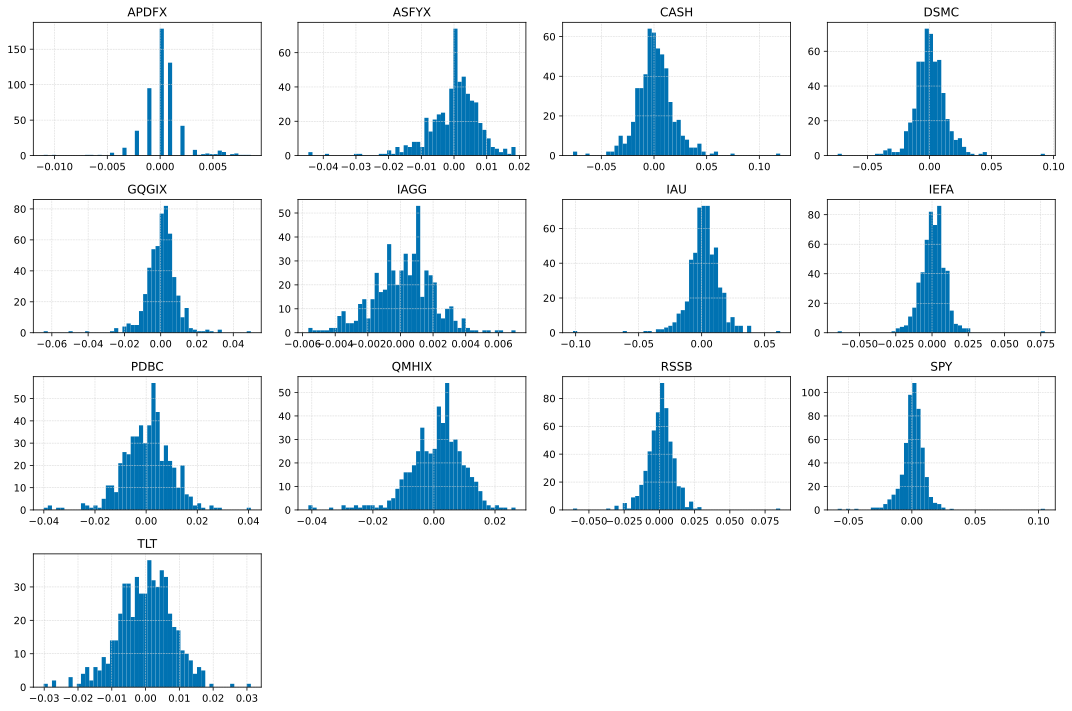

In [6]:
axes = returns_df.hist(figsize = (15, 10), bins = 50)
# Customize grid for all subplots
for ax in axes.flatten():  # Flatten 
    ax.grid(
        True, 
        linestyle='--',   # Dashed lines
        linewidth=0.5,    # Thinner lines
        color='lightgray' # Pale color
    )

plt.tight_layout()
plt.show()
ax.grid()

Display basic statistics:

In [7]:
print(f"Data shape: {returns_df.shape}")
print(f"Date range: {returns_df.index[0].date()} to {returns_df.index[-1].date()}")

Data shape: (540, 13)
Date range: 2024-01-03 to 2026-02-27


### **3. Annualized Covariance Matrix and Individual Asset Volatilities**

To understand the risk profile of the portfolio, we calculate the annualized covariance matrix and individual asset volatilities:

In [8]:
# Annualized covariance matrix (252 trading days)
def annual_cov_vol(returns, td):
    covar_matrix = returns.cov()*td
    volatilities = returns.std()*np.sqrt(td)
    return covar_matrix, volatilities  

# Annualized volatilities
volatilities = annual_cov_vol(returns_df, 252)[1]

# Print results
print("Annualized Volatilities:\n")
for asset, vol in volatilities.items():
  print(f"{asset}: {vol:.2%}")

Annualized Volatilities:

APDFX: 3.27%
ASFYX: 12.28%
CASH: 28.69%
DSMC: 20.53%
GQGIX: 14.11%
IAGG: 2.99%
IAU: 20.46%
IEFA: 14.58%
PDBC: 15.11%
QMHIX: 14.38%
RSSB: 16.04%
SPY: 16.08%
TLT: 12.85%


In [9]:
print("Covariance Matrix:\n")
covar_matrix = annual_cov_vol(returns_df, 252)[0]
print(covar_matrix)

Covariance Matrix:

          APDFX     ASFYX      CASH      DSMC     GQGIX      IAGG       IAU  \
APDFX  0.001071  0.000802  0.002581  0.002859  0.001398  0.000252 -0.000014   
ASFYX  0.000802  0.015084  0.005683  0.007771  0.007162  0.000011  0.010321   
CASH   0.002581  0.005683  0.082332  0.036083  0.009114  0.000322 -0.001885   
DSMC   0.002859  0.007771  0.036083  0.042142  0.012718  0.000687  0.002757   
GQGIX  0.001398  0.007162  0.009114  0.012718  0.019907  0.000426  0.006355   
IAGG   0.000252  0.000011  0.000322  0.000687  0.000426  0.000895  0.000880   
IAU   -0.000014  0.010321 -0.001885  0.002757  0.006355  0.000880  0.041846   
IEFA   0.002052  0.007910  0.015385  0.019870  0.012569  0.000921  0.008802   
PDBC   0.000304  0.004592  0.002560  0.008485  0.005529 -0.000753  0.014557   
QMHIX  0.000332  0.013021 -0.001440  0.000287  0.006507 -0.000288  0.009279   
RSSB   0.002611  0.006748  0.019214  0.023308  0.013099  0.001843  0.006704   
SPY    0.002397  0.006928  0.021

In case we want to emphasize recent trends, we can use an exponentially weighted covariance matrix with a decay factor:

In [14]:
# Exponentially weighted covariance with 0.94 decay factor
tickers = data.columns.tolist()
ewm_cov = returns_df.ewm(alpha = 0.06).cov().iloc[-len(tickers):, :]*252
ewm_vol = np.sqrt(np.diag(ewm_cov))
print("Exponentially Weighted Covariance:\n")
print(ewm_cov)
print("\nExponentially Weighted Volatility:\n")
print(ewm_vol)

Exponentially Weighted Covariance:

                     APDFX     ASFYX      CASH      DSMC     GQGIX      IAGG  \
Date                                                                           
2026-02-27 APDFX  0.000506 -0.000573  0.001524  0.000246  0.000283 -0.000092   
           ASFYX -0.000573  0.022222  0.009898  0.008413  0.011779 -0.000435   
           CASH   0.001524  0.009898  0.130033  0.033586  0.007054 -0.001918   
           DSMC   0.000246  0.008413  0.033586  0.033097  0.005837 -0.000699   
           GQGIX  0.000283  0.011779  0.007054  0.005837  0.014078 -0.000412   
           IAGG  -0.000092 -0.000435 -0.001918 -0.000699 -0.000412  0.000238   
           IAU   -0.003959  0.039444 -0.005439 -0.000571  0.013561  0.000116   
           IEFA   0.000166  0.013419  0.012353  0.010564  0.008957 -0.000246   
           PDBC  -0.001499  0.018869 -0.003986  0.003041  0.006311 -0.000163   
           QMHIX -0.000206  0.016900  0.002788  0.003169  0.009835 -0.000477   
    

### **4. Baseline Allocations**

A good practice for risk parity is inverse volatility weighting. This method allocates more capital to less volatile assets, balancing the risk exposure

The allocations set by client:

In [10]:
if portfolio_data == 'a':
    weights = {'TLT': .05, 'IEFA': .11, 'PDBC': .10, 'IAGG': .05, 'IAU': .10, 'DSMC': .06, 'RSSB': .10, 'ASFYX': .10,
                 'APDFX': .05, 'QMHIX': .10, 'CASH': .01, 'GQGIX': .06, 'SPY': .11}
elif portfolio_data == 'b':
    weights = {'SPY': .60, 'CAOS': .40}
elif portfolio_data == 'c':
    weights = {'SPY': .60, 'AGG': .40}
else:
    weights = {'GAL': 1.00}

#### **4.1 Allocation's Distribution**

As mentioned above, the asset allocation is based on inverse volatility.

Based on the client's preestablished weights:

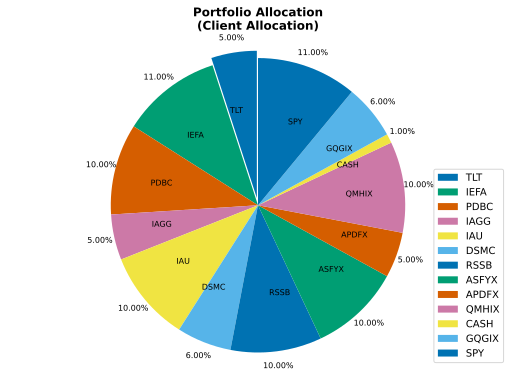

In [11]:
explode = (0.05,) + (0,)*(len(weights.keys()) - 1)

fig, ax = plt.subplots(figsize=(9,6))
ax.set_title('Portfolio Allocation\n(Client Allocation)', fontsize = 12, fontweight = 'bold')
ax.pie([val * 100 for val in list(weights.values())],
       labels = list(weights.keys()),
       startangle = 90,
       autopct = '%1.2f%%', pctdistance = 1.1, labeldistance = .6,
       textprops={'fontsize': 8}, explode = explode)
ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
ax.legend(loc = 'lower right', fontsize = 10)
plt.show();

In order to achieve **true risk parity**, we need to equalize the risk contribution of each asset. This involves solving an optimization problem which can be done using `scipy.optimize`. Please refer to the module `optimize_portfolio.py`.

In [12]:
from optimize_portfolio import *
risk_budget_objective(list(weights.values()), covar_matrix.values)

np.float64(0.00028539828299044897)

In [15]:
from optimize_portfolio import *
# Calculate risk parity weights
rp_weights = optimize_risk_parity(covar_matrix.values)
rp_weights_series = pd.Series(rp_weights, index = tickers)

print("Risk Parity Weights:\n")
for asset, weight in rp_weights_series.items():
  print(f"{asset}: {weight:.2%}")

Risk Parity Weights:

APDFX: 21.57%
ASFYX: 5.17%
CASH: 2.95%
DSMC: 2.77%
GQGIX: 4.28%
IAGG: 29.44%
IAU: 3.90%
IEFA: 3.36%
PDBC: 6.04%
QMHIX: 6.55%
RSSB: 2.87%
SPY: 3.31%
TLT: 7.79%


Weighted risk contribution Pie-Chart:

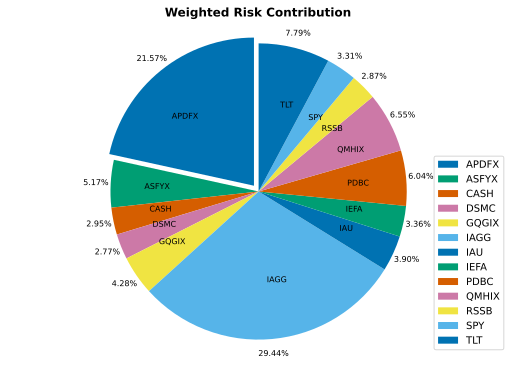

In [16]:
explode = (0.05,) + (0,)*(len(weights.keys()) - 1)

fig, ax = plt.subplots(figsize=(9,6))
ax.set_title('Weighted Risk Contribution', fontsize = 12, fontweight = 'bold')
ax.pie((rp_weights_series*100).round(2).tolist(),
       labels = rp_weights_series.index.tolist(),
       startangle = 90,
       autopct = '%1.2f%%', pctdistance = 1.1, labeldistance = .6,
       textprops={'fontsize': 8}, explode = explode)
ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
ax.legend(loc = 'lower right', fontsize = 10)
plt.show();

To confirm the optimization worked, we calculate the actual risk contributions and ensure they're balanced:

In [17]:
def calculate_risk_contributions(weights, covar_matrix):
    """
    Calculate individual asset risk contributions
    """
    portfolio_vol = np.sqrt(np.dot(weights, np.dot(covar_matrix, weights)))
    marginal_cont = np.dot(covar_matrix, weights)/portfolio_vol
    cont = weights*marginal_cont
    return cont/portfolio_vol

risk_contrib = calculate_risk_contributions(rp_weights, covar_matrix.values)
risk_contrib_series = pd.Series(risk_contrib, index = tickers)

print("Risk Contributions:\n")
for asset, cont in risk_contrib_series.items():
    print(f"{asset}: {cont:.2%}")

Risk Contributions:

APDFX: 7.69%
ASFYX: 7.69%
CASH: 7.69%
DSMC: 7.69%
GQGIX: 7.69%
IAGG: 7.69%
IAU: 7.69%
IEFA: 7.69%
PDBC: 7.69%
QMHIX: 7.69%
RSSB: 7.69%
SPY: 7.69%
TLT: 7.69%


#### **4.2 Using Specialized Optimization Libraries**

For a more streamlined approach, we consider libraries tailored for risk parity optimization. The `riskparityportfolio` library, for instance, simplifies the process:

**Install library:**

In [17]:
#conda install conda-forge::riskparityportfolio

In [18]:
"""
import riskparityportfolio as rpp
import numpy as np

# Design risk parity portfolio using the library
# The 'design' function expects a covariance matrix (Sigma) and a risk budget
# vector (b)
# For equal risk contribution, 'b' should be a vector of ones with length equal
# to the number of assets.
num_assets = len(tickers)
risk_budget_vector = np.ones(num_assets)

rpp_weights = rpp.design(Sigma = covar_matrix.values, b = risk_budget_vector)

print("Risk_Parity_Portfolio Library Weights:\n")
rpp_weights_series = pd.Series(rpp_weights.flatten(), index = tickers)
for asset, weight in rpp_weights_series.items():
  print(f"{asset}: {weight:.2%}")
"""

'\nimport riskparityportfolio as rpp\nimport numpy as np\n\n# Design risk parity portfolio using the library\n# The \'design\' function expects a covariance matrix (Sigma) and a risk budget\n# vector (b)\n# For equal risk contribution, \'b\' should be a vector of ones with length equal\n# to the number of assets.\nnum_assets = len(tickers)\nrisk_budget_vector = np.ones(num_assets)\n\nrpp_weights = rpp.design(Sigma = covar_matrix.values, b = risk_budget_vector)\n\nprint("Risk_Parity_Portfolio Library Weights:\n")\nrpp_weights_series = pd.Series(rpp_weights.flatten(), index = tickers)\nfor asset, weight in rpp_weights_series.items():\n  print(f"{asset}: {weight:.2%}")\n'

**Note:** There are differences on the results between the approach employed in *Section-4.1* and the specialized library `riskparityportfolio`, as the algorithm and the approcah in which both computations are relied on may differ.  

For advanced features, `Riskfolio-Lib` offers extensive tools for portfolio optimization and visualization:

In [18]:
import riskfolio as rp

# Create portfolio object
port = rp.Portfolio(returns = returns_df)

# Calculate historical mean returns and covariance matrix
port.assets_stats(method_mu = 'hist', method_cov = 'hist')

# Optimize for risk parity
riskfolio_weights = port.rp_optimization(model = 'Classic',
                                         rm = 'MV', # Mean variance
                                         rf = 0.02, # Example risk-free rate (approx. 2%)
                                         b = None # Equal risk budgeting
                                         )
print("Riskfolio-Lib Parity Weights:\n")
for asset in tickers:
  weight = riskfolio_weights.loc[asset, 'weights']
  print(f"{asset}: {weight:.2%}")

Riskfolio-Lib Parity Weights:

APDFX: 21.57%
ASFYX: 5.17%
CASH: 2.95%
DSMC: 2.77%
GQGIX: 4.28%
IAGG: 29.44%
IAU: 3.90%
IEFA: 3.36%
PDBC: 6.04%
QMHIX: 6.55%
RSSB: 2.87%
SPY: 3.31%
TLT: 7.79%


We can also use `Riskfolio-Lib` to visualize the risk contributions of our portfolio:

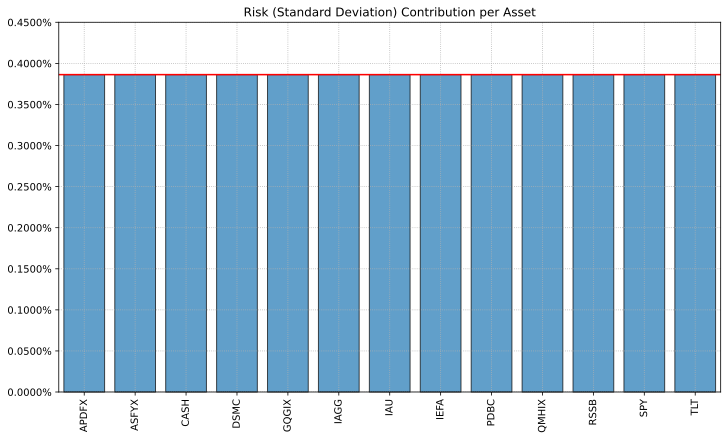

In [19]:
ax = rp.plot_risk_con(riskfolio_weights,
                      cov = port.cov,
                      returns = port.returns,
                      rm = 'MV',
                      rf = 0.02,
                      alpha = 0.05,
                      color = "tab:blue",
                      height = 6,
                      width = 10,
                      ax = None
                      )

### **5. Rebalancing and Backtesting**



#### **5.1 Rebalancing Strategies**

Risk parity portfolios need regular rebalancing because asset volatilities and correlations shift over time. Without adjustments, the balance of risk contributions across assets will drift.



##### **5.1.1 Fixed schedule rebalancing** is a simple and effective way to manage this. A monthly schedule often strikes a good balance between stating aligned with risk parity goals and minimizing transaction costs.

**Note:** Hava a look at `schedule_rebalancing.py` module.

For the example purpose, we add a proportional random noise to each asset in order to define a `target_allocationc` and make the proper calculations corresponding to the *fixed schedule rebalancing*.

In [20]:
#%load_ext autoreload
#%autoreload 2
from schedule_rebalancing import *
last_rebalance = datetime(2026, 1, 13)
current_date = datetime.now()

if should_rebalance(last_rebalance):
  print("Time to rebalance portfolio")

  # Current portfolio allocation

  current_allocation = pd.Series(weights)

  # Target portfolio weights
  # Set random seed for reproductibility
  np.random.seed(123)
  # Add proportional noise (e.g., ±5%)
  noise_factor = 0.05
  noise = np.random.lognormal(0, noise_factor,
                              size = len(current_allocation))
  target_allocation = pd.Series(current_allocation*noise)

  portfolio_value = float(input("Enter the Portfolio value (USD): "))
  trades = calculate_rebalancing_trades(current_allocation, target_allocation,
                                        portfolio_value)

  print("Required trades:\n")
  for asset, trade_amount in trades.items():
    action = "BUY" if trade_amount > 0 else "SELL"
    print(f"{action} ${abs(trade_amount):,.0f} of {asset}")

Time to rebalance portfolio


Enter the Portfolio value (USD):  100000


Required trades:

SELL $264 of TLT
BUY $562 of IEFA
BUY $142 of PDBC
SELL $363 of IAGG
SELL $285 of IAU
BUY $516 of DSMC
SELL $1,143 of RSSB
SELL $212 of ASFYX
BUY $327 of APDFX
SELL $424 of QMHIX
BUY $852 of SPY


##### **5.1.2 Volatility-based triggers** offer a more dynamic way to rebalance. This method kicks in when the volatility of an asset moves beyond a set threshold, such as a 20% deviation from its historical average.

Check `vol_trigg_check.py` module.

In [21]:
import numpy as np
from vol_trigg_check import *
volatility_trigger_check(returns_df, lookback_days = 60, threshold = 0.20)

Volatility trigger activated for:

APDFX: 33.9% volatility change
GQGIX: 25.3% volatility change
IAGG: 47.8% volatility change
IAU: 109.9% volatility change
IEFA: 26.9% volatility change
PDBC: 32.6% volatility change
SPY: 35.6% volatility change
TLT: 39.2% volatility change


True

#### **5.2 Backtesting and Performance Metrics**

Backtesting is essential to ensure our risk parity strategy holds up under real-world conditions. **Walk-forward backtesting** is particularly useful because it evaluates performance using only the data available at the time, offering a more realistic assessment.

Check `walk_fwd_btest.py` module.

**Backtesting:**

In [23]:
#%run walk_fwd_btest.py

**Performance Metrics:**

##### **Generate Report**

In [22]:
# Benchmark returns (State Street Global Allocation ETF)
data_benchmark = pd.read_csv('State_Street_ETF.csv', index_col = 0, parse_dates = True)
data_benchmark = data_benchmark.loc['2024-01-02':]
data_benchmark.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 541 entries, 2024-01-02 to 2026-02-27
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   GAL     541 non-null    float64
dtypes: float64(1)
memory usage: 8.5 KB


**Benchmark returns (State Street Global Allocation ETF):**

In [23]:
returns_benchmark = data_benchmark.pct_change().dropna()

In [24]:
def return_dividends(portfolio_data: str):
    if portfolio_data == 'a':
        dividends = 'divs_aspect_partners.csv'
    elif portfolio_data == 'b':
        dividends = 'divs_SPY_Long_Vol.csv'
    elif portfolio_data == 'c':
        dividends = 'divs_SPY_Long_Bond.csv'
    else:
        dividends = 'divs_State_Street_ETF.csv'

    return dividends

In [25]:
from walk_fwd_btest import *
from performance_metrics import *
returns_df = data.pct_change().dropna()
# Run the backtest
#backtest_results = walk_forward_backtest(returns_df, lookback_months = 24, initial_value = 10000)

    
backtest_results = walk_forward_backtest(
        returns = returns_df, 
        rebalance_frequency = 'quarterly', 
        lookback_months = 1, 
        prices = data,
        div_csv_path = return_dividends(portfolio_data)
        )

# Get benchmark returns (SPY)
benchmark_returns = returns_benchmark['GAL'].resample('ME').apply(lambda x: (1 + x).prod() - 1)

# Calculate performance metrics
metrics = pd.Series(calculate_performance_metrics(
                    backtest_results = backtest_results, 
                    inflation_rate = 0.025, 
                    risk_free_rate = 0.02,
                    benchmark_returns = benchmark_returns
                    ))

Start Balance: $10,000.00
End Balance: $13,877.97
Period: 2.00 years (2024-02-29 to 2026-02-28)
End Balance (Inflation Adj., 2.5% p.a.): $13,209.25
Annualized Return (CAGR): 17.80%
Annualized Return (CAGR, Inflation Adj.): 14.93%
Annualized Volatility (Std Dev): 4.54%
Best Year: 14.17%
Worst Year: 7.44%
Maximum Drawdown: -1.25%
Sharpe Ratio (rf = 2.0%): 0.89
Sortino Ratio (rf = 2.0%): 2.20
Benchmark Correlation: 0.56
Arithmetic Mean (monthly): 1.33%
Arithmetic Mean (annualized): 15.93%
Geometric Mean (monthly): 1.32%
Geometric Mean (annualized): 1.32%
Standard Deviation (monthly): 1.31%
Standard Deviation (annualized): 4.54%
Downside Deviation (monthly): 30.64%
Beta (State Street Global Allocation ETF as benchmark): 0.44
R-Squared: 0.3096
Alpha (annualized): 0.0850
Treynor Ratio (%): 36.04%
Modigliani-Modigliani (M²) Measure: 7.11%
Active Return (annualized): 2.60%
Tracking Error (annualized): 4.97%
Information Ratio: 0.31
Skewness: 0.5454
Excess Kurtosis: 1.4630
Historical VaR (5%): -

##### **Risk and Return Metrics**

Here, we display the risk and return metrics of the entire set of portfolios.

In [26]:
from walk_fwd_btest import *
from performance_metrics import *

portfolio_files = {
    'Aspect Partners Risk Parity': 'aspect_partners.csv',
    'SPY + Long Vol': 'SPY_Long_Vol.csv',
    'SPY + Long Bond': 'SPY_Long_Bond.csv',
    'State Street Global Allocation ETF': 'State_Street_ETF.csv',
}

data_porfls = {
    name: pd.read_csv(path, index_col=0, parse_dates=True)
    for name, path in portfolio_files.items()
}

returns_df = [data.pct_change().dropna() for data in list(data_porfls.values())]

dividends_porfls = ['divs_aspect_partners.csv', 
                   'divs_SPY_Long_Vol.csv', 
                   'divs_SPY_Long_Bond.csv', 
                   'divs_State_Street_ETF.csv']

backtest_results = [walk_forward_backtest(
        returns = returns, 
        rebalance_frequency = 'quarterly', 
        lookback_months = 1, 
        prices = data,
        div_csv_path = return_dividends(dividends)
        ) for returns, dividends in zip(returns_df, dividends_porfls)]

# Get benchmark returns (SPY)
benchmark_returns = returns_benchmark['GAL'].resample('ME').apply(lambda x: (1 + x).prod() - 1)

# Calculate performance metrics
metrics = [pd.Series(calculate_performance_metrics(
                    backtest_results = results, 
                    inflation_rate = 0.025, 
                    risk_free_rate = 0.02,
                    benchmark_returns = benchmark_returns
                    )) for results in backtest_results]
metrics_df = pd.concat(metrics, axis = 1)
metrics_df.columns = list(data_porfls.keys())

Start Balance: $10,000.00
End Balance: $12,653.96
Period: 2.00 years (2024-02-29 to 2026-02-28)
End Balance (Inflation Adj., 2.5% p.a.): $12,044.22
Annualized Return (CAGR): 12.49%
Annualized Return (CAGR, Inflation Adj.): 9.75%
Annualized Volatility (Std Dev): 4.76%
Best Year: 10.43%
Worst Year: 6.82%
Maximum Drawdown: -1.38%
Sharpe Ratio (rf = 2.0%): 0.57
Sortino Ratio (rf = 2.0%): 1.63
Benchmark Correlation: 0.68
Arithmetic Mean (monthly): 0.95%
Arithmetic Mean (annualized): 11.46%
Geometric Mean (monthly): 0.95%
Geometric Mean (annualized): 0.95%
Standard Deviation (monthly): 1.37%
Standard Deviation (annualized): 4.76%
Downside Deviation (monthly): 42.78%
Beta (State Street Global Allocation ETF as benchmark): 0.56
R-Squared: 0.4654
Alpha (annualized): 0.0248
Treynor Ratio (%): 18.61%
Modigliani-Modigliani (M²) Measure: 5.31%
Active Return (annualized): -2.72%
Tracking Error (annualized): 4.30%
Information Ratio: -0.68
Skewness: 0.7918
Excess Kurtosis: 1.5379
Historical VaR (5%): 

In [27]:
new_list = (metrics_df.iloc[-2]*100).tolist()
metrics_df_copy = metrics_df.copy()
metrics_df_copy.iloc[-2] = new_list
metrics_df_copy.round(3)

,Aspect Partners Risk Parity,SPY + Long Vol,SPY + Long Bond,State Street Global Allocation ETF
Start_Balance,10000.000,10000.000,10000.000,10000.000
End_Balance,12653.963,11223.492,11930.985,13425.961
End_Balance_Real,12044.225,10682.681,11356.084,12779.023
CAGR,0.125,0.059,0.092,0.159
CAGR_Real,0.097,0.034,0.066,0.130
Arithmetic_Mean_Monthly,0.010,0.005,0.007,0.012
Arithmetic_Mean_Annual,0.115,0.056,0.087,0.144
Geometric_Mean_Monthly,0.009,0.005,0.007,0.012
Geometric_Mean_Annual,0.120,0.057,0.088,0.152
Annualized_Volatility,0.048,0.021,0.057,0.058
